In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv")
test_data = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv")

print("shape of the training data:",train_data.shape)
print("shape of the test data:", test_data.shape)

shape of the training data: (40000, 12)
shape of the test data: (10000, 11)


### Identifying data types of different columns:

In [3]:
print("Data types of differrnt columns:\n\n", train_data.dtypes)

Data types of differrnt columns:

 id               int64
airline         object
flight          object
source          object
departure       object
stops           object
arrival         object
destination     object
class           object
duration       float64
days_left      float64
price            int64
dtype: object


# Descriptive statistics of Numerical Columns

In [4]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,40000.0,19999.500000,11547.149720,0.00,9999.75,19999.50,29999.25,39999.00
duration,36987.0,12.004088,7.108063,0.83,6.67,11.08,15.92,47.08
days_left,35562.0,26.197936,13.469232,1.00,15.00,26.00,38.00,49.00
price,40000.0,20801.490250,22729.148420,1105.00,4687.00,7353.00,42521.00,114704.00


- id is an identifier column and it doesn't add any value for training.
- So, lets drop the id column

In [5]:
train_id_dropped = train_data.drop("id", axis = 1)
train_id_dropped.shape

(40000, 11)

# Identifying and Handling Missing Values
- Missing values are identified using the `isnull()` function.
- KNNImputer is used for numerical columns while SimpleImputer is used for categorical columns

In [6]:
train_id_dropped.isnull().sum()

airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

In [8]:
numerical_transformers = Pipeline(steps = [
    ("imputer", KNNImputer()),
    ("std_scalar", StandardScaler()),
])

categorical_transformers = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore")),
])

# Identifying and handling duplicates

In [9]:
train_id_dropped[train_id_dropped.duplicated()]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
1107,Indigo,NaN,Mumbai,Morning,zero,Morning,Delhi,Economy,2.17,NaN,2339
2210,Vistara,UK-854,Bangalore,Evening,one,Late_Night,Delhi,Economy,5.75,NaN,4111
2669,Vistara,UK-826,Chennai,Afternoon,one,Morning,Hyderabad,Economy,20.58,NaN,12990
4733,Indigo,NaN,Mumbai,Afternoon,one,Night,Kolkata,Economy,6.75,NaN,2835
5578,Air_India,AI-867,Mumbai,Night,one,Morning,Kolkata,Business,11.50,NaN,49725
...,...,...,...,...,...,...,...,...,...,...,...
39318,Vistara,UK-977,Delhi,Evening,one,Afternoon,Hyderabad,Business,17.25,NaN,53937
39353,Air_India,AI-762,Delhi,Night,one,Night,Hyderabad,Business,25.00,NaN,47408
39542,Vistara,UK-816,Bangalore,Morning,one,Evening,Kolkata,Business,8.08,NaN,62188
39660,Indigo,6.00E-282,Delhi,Morning,zero,Afternoon,Kolkata,Economy,2.17,NaN,3999


In [10]:
train_dup_dropped = train_id_dropped.drop_duplicates()
train_dup_dropped.shape

(39750, 11)

There were **250 duplicates** in the dataset and they were all **dropped**.

# Identifying and Handling outliers

In [11]:
numerical_columns = train_dup_dropped.select_dtypes(include=np.number).columns.tolist()

outlier_indices_to_drop = set()

for column in numerical_columns:
    Q1 = train_dup_dropped[column].quantile(0.25)
    Q3 = train_dup_dropped[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_condition = (train_dup_dropped[column] < lower_bound) | (train_dup_dropped[column] > upper_bound)
    outlier_indices_to_drop.update(train_dup_dropped[outliers_condition].index.tolist())
    
train_out_dropped = train_dup_dropped.drop(outlier_indices_to_drop)
print(f"There are {len(outlier_indices_to_drop)} outliers in the train dataset")
print(f"Shape of the train_data after dropping outliers is {train_out_dropped.shape}")

There are 243 outliers in the train dataset
Shape of the train_data after dropping outliers is (39507, 11)


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


### Visualizations of the dataset

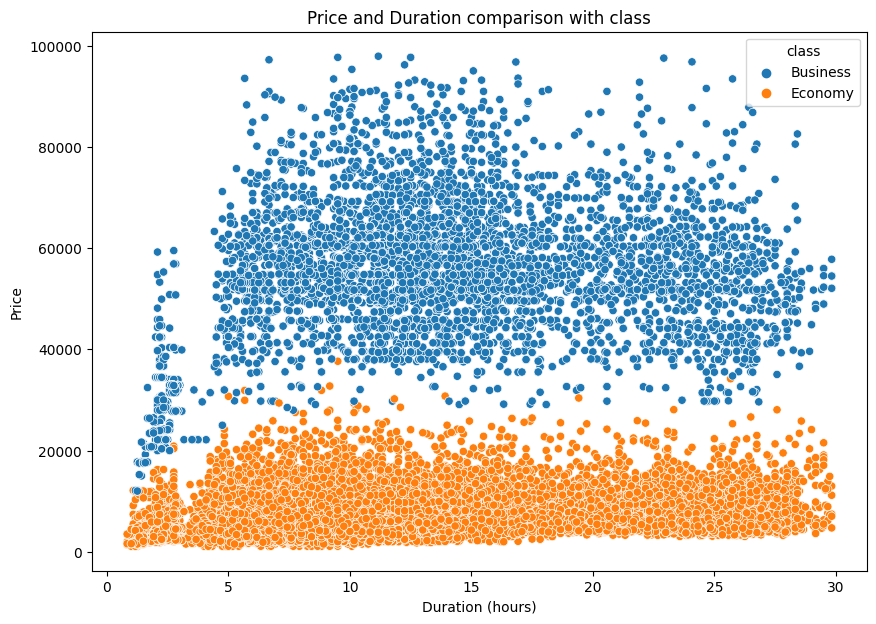

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=train_out_dropped, x='duration', y='price', hue='class')
plt.title('Price and Duration comparison with class')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.show()

- This graph shows that the **duration** of the flight and the **price** of the flight have **weak correlation**.
- But the **class** and **price** have **strong correlation**.

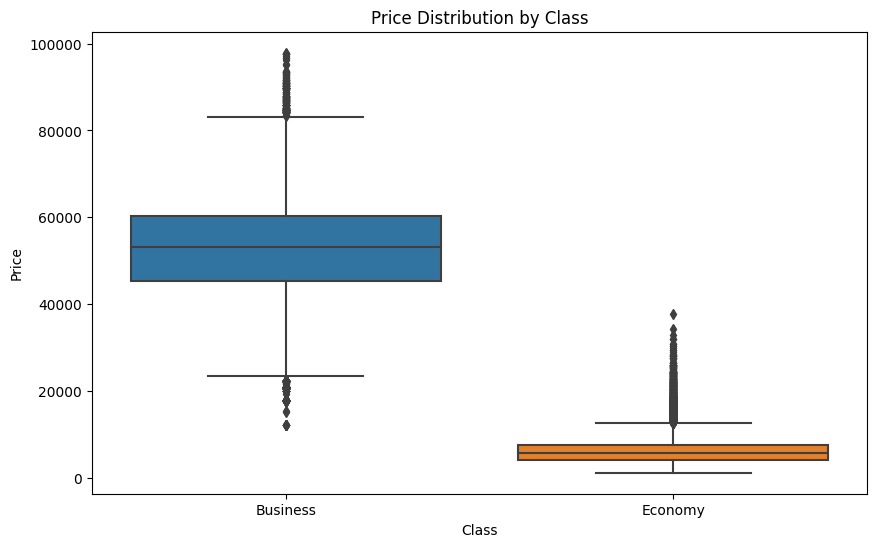

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_out_dropped, x='class', y='price')
plt.title('Price Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Price')
plt.show()


- This graph shows that most of the **Economy** class flights have ticket price **below 20000**.
- Also most of the **business** class flights have price in **range** of **40000** to **60000**.
- But some of the **business** class flights are **less than 20000** and some are **greater than 80000**.

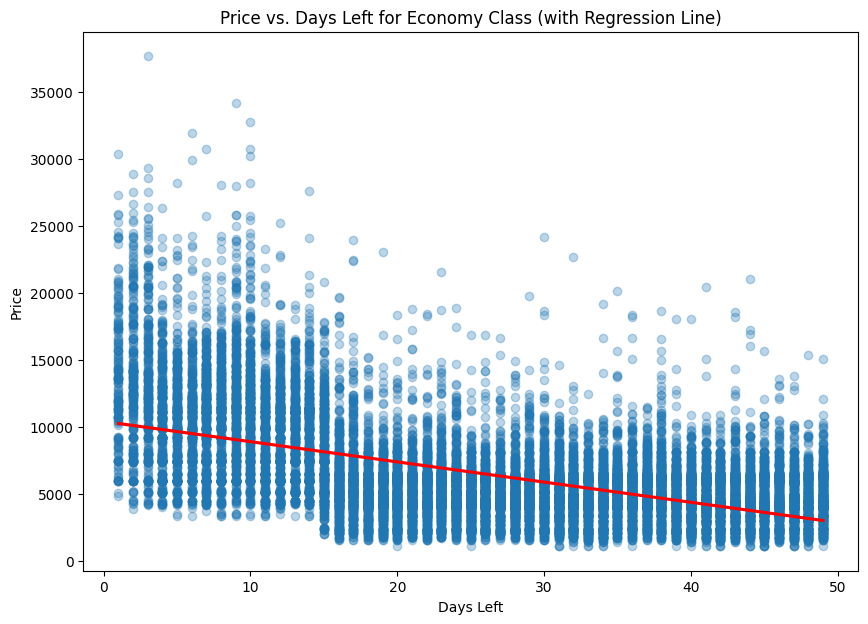

In [14]:
plt.figure(figsize=(10, 7))
sns.regplot(data=train_out_dropped[train_out_dropped["class"] == "Economy"],
            x='days_left',
            y='price',
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red'}
    )
plt.title('Price vs. Days Left for Economy Class (with Regression Line)')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.show()

- This graph shows that the **price** and **days left** are **negatively correlated**.

In [15]:
from sklearn.model_selection import train_test_split

X_full = train_out_dropped.drop("price", axis = 1)
y_full = train_out_dropped["price"]

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size = 0.2, random_state = 42)

categorical_columns = X_full.select_dtypes(include = "object").columns.tolist()
numerical_columns = X_full.select_dtypes(include = np.number).columns.tolist()

In [16]:
preprocessor = ColumnTransformer(
    transformers = [
        ("numerical", numerical_transformers, numerical_columns),
        ("categorical", categorical_transformers, categorical_columns)],
    remainder  = "drop")

In [17]:
models_to_train = [
    ("Linear Regression", LinearRegression()),
    ("Lasso Regression", Lasso(random_state = 42)),
    ("SGD Regressor", SGDRegressor(random_state = 42)),
    ("Random Forest Regressor", RandomForestRegressor(random_state = 42)),
    ("GradientBoostingRegressor", GradientBoostingRegressor(random_state = 42)),
    ("K nearest neighbors", KNeighborsRegressor()),
    ("XGB Regressor", XGBRegressor(random_state = 42)),
    ("LGBM Regressor", LGBMRegressor(random_state = 42))
]

In [18]:
trained_models = {}
model_performance = {}

for model_name, model in models_to_train:
    print(f"\nTraining {model_name}:")
    
    model_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    model_pipeline.fit(X_train, y_train)
    trained_models[model_name] = model_pipeline

    y_pred = model_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5

    model_performance[model_name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

    print(f"Scores for {model_name} are:")
    print(f"RMSE: {rmse}")
    print(f"r2 score: {r2}")

print("ALL MODELS ARE TRAINED AND THEIR SCORES ARE CALCULATED")


Training Linear Regression:
Scores for Linear Regression are:
RMSE: 6355.405656253899
r2 score: 0.9223169955696082

Training Lasso Regression:
Scores for Lasso Regression are:
RMSE: 6363.947688256857
r2 score: 0.9221080343531222

Training SGD Regressor:
Scores for SGD Regressor are:
RMSE: 6351.191878053254
r2 score: 0.9224199726104931

Training Random Forest Regressor:
Scores for Random Forest Regressor are:
RMSE: 3406.446978677749
r2 score: 0.9776826446512272

Training GradientBoostingRegressor:
Scores for GradientBoostingRegressor are:
RMSE: 5139.45536991702
r2 score: 0.9491988364321868

Training K nearest neighbors:
Scores for K nearest neighbors are:
RMSE: 7170.247815897788
r2 score: 0.9011201512954699

Training XGB Regressor:
Scores for XGB Regressor are:
RMSE: 3890.337863767169
r2 score: 0.970891883686386

Training LGBM Regressor:
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006468 seconds.
You can set `force_row_wise=true` to remove th

### Hyperparameter Tuning:
Top 3 models:
- **RandomForestRegressore:** r2 score = 0.977
- **XGBRegressor:** r2 score = 0.970
- **LGBMRegressor**: r2 score = 0.969

In [19]:
param_grid_rf = {
    'regressor__n_estimators': [500, 700],
    'regressor__max_depth': [20, 25],
    'regressor__min_samples_split': [6],
    'regressor__max_features': [0.8]
}

num_combinations = 1
for values in param_grid_rf.values():
    num_combinations *= len(values)
total_fits = num_combinations * 3
print(f"Total number of combinations to test: {num_combinations}")
print(f"Estimated total number of fits for GridSearchCV (including CV folds): {total_fits}")


rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search_rf = GridSearchCV(estimator=rf_pipeline,
                              param_grid=param_grid_rf,
                              cv=3,
                              scoring='r2',
                              n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

trained_models["Random Forest Regressor(Tuned)"] = grid_search_rf.best_estimator_

y_pred = grid_search_rf.best_estimator_.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

model_performance["Random Forest Regressor(Tuned)"] = {
    "RMSE": rmse,
    "R2 Score": r2
}

print("Scores for are Random Forest Regressor(Tuned):")
print(f"RMSE: {rmse}")
print(f"r2 score: {r2}")

print(f"\nBest parameters for Random Forest: {grid_search_rf.best_params_}")

Total number of combinations to test: 4
Estimated total number of fits for GridSearchCV (including CV folds): 12
Scores for are Random Forest Regressor(Tuned):
RMSE: 3463.013166997976
r2 score: 0.9769353033484477

Best parameters for Random Forest: {'regressor__max_depth': 25, 'regressor__max_features': 0.8, 'regressor__min_samples_split': 6, 'regressor__n_estimators': 500}


In [20]:
param_grid_xgb = {
    'regressor__n_estimators': [700, 800],
    'regressor__learning_rate': [0.1, 0.15],
    'regressor__max_depth': [7, 9],
    'regressor__subsample': [0.85, 0.95],
    'regressor__gamma': [0.1],
    'regressor__reg_alpha': [0.5, 0.6],
    'regressor__reg_lambda': [0.85],
}

num_combinations = 1
for values in param_grid_xgb.values():
    num_combinations *= len(values)
total_fits = num_combinations * 3 

print(f"Total number of combinations to test: {num_combinations}")
print(f"Total number of fits for GridSearchCV (including CV folds): {total_fits}")

xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(random_state = 42))
])

grid_search_xgb = GridSearchCV(estimator=xgb_pipeline,
                               param_grid=param_grid_xgb,
                               cv=3,
                               scoring='r2',
                               n_jobs=-1)

grid_search_xgb.fit(X_train, y_train)

trained_models["XGB Regressor(Tuned)"] = grid_search_xgb.best_estimator_

y_pred = grid_search_xgb.best_estimator_.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

model_performance["XGB Regressor(Tuned)"] = {
    "RMSE": rmse,
    "R2 Score": r2
}

print("Scores for XGB Regressor(Tuned) are:")
print(f"RMSE: {rmse}")
print(f"r2 score: {r2}")

print(f"\nBest parameters for XGBoost: {grid_search_xgb.best_params_}")

Total number of combinations to test: 32
Total number of fits for GridSearchCV (including CV folds): 96
Scores for XGB Regressor(Tuned) are:
RMSE: 3221.465923423806
r2 score: 0.9800406430550861

Best parameters for XGBoost: {'regressor__gamma': 0.1, 'regressor__learning_rate': 0.15, 'regressor__max_depth': 9, 'regressor__n_estimators': 800, 'regressor__reg_alpha': 0.5, 'regressor__reg_lambda': 0.85, 'regressor__subsample': 0.95}


In [21]:
param_grid_lgbm = {
    'regressor__n_estimators': [750, 800],
    'regressor__learning_rate': [0.1, 0.12],
    'regressor__num_leaves': [70],
    'regressor__max_depth': [15],
    'regressor__colsample_bytree': [0.8, 0.9],
    'regressor__subsample': [0.7, 0.8],
    'regressor__reg_alpha': [0.5],
    'regressor__reg_lambda': [0.1],
    'regressor__min_child_samples': [20]
}

num_combinations = 1
for values in param_grid_lgbm.values():
    num_combinations *= len(values)
total_fits = num_combinations * 3
print(f"Total number of combinations to test: {num_combinations}")
print(f"Estimated total number of fits for GridSearchCV (including CV folds): {total_fits}")

lgbm_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(random_state=42, n_jobs=1, verbose=-1))
])

grid_search_lgbm = GridSearchCV(estimator=lgbm_pipeline,
                                param_grid=param_grid_lgbm,
                                cv=3,
                                scoring='r2',
                                n_jobs=-1)


grid_search_lgbm.fit(X_train, y_train)

trained_models["LGBM Regressor(Tuned)"] = grid_search_lgbm.best_estimator_

y_pred = grid_search_lgbm.best_estimator_.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

model_performance["LGBM Regressor(Tuned)"] = {
    "RMSE": rmse,
    "R2 Score": r2
}

print("Scores for LGBM Regressor(Tuned) are:")
print(f"RMSE: {rmse}")
print(f"r2 score: {r2}")

print(f"\nBest parameters for LightGBM: {grid_search_lgbm.best_params_}")

Total number of combinations to test: 16
Estimated total number of fits for GridSearchCV (including CV folds): 48
Scores for LGBM Regressor(Tuned) are:
RMSE: 3412.4883526625076
r2 score: 0.9776034142684084

Best parameters for LightGBM: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 15, 'regressor__min_child_samples': 20, 'regressor__n_estimators': 800, 'regressor__num_leaves': 70, 'regressor__reg_alpha': 0.5, 'regressor__reg_lambda': 0.1, 'regressor__subsample': 0.7}


In [22]:
performance = pd.DataFrame(model_performance).T.sort_values(by="R2 Score", ascending=False)
performance

,RMSE,R2 Score
XGB Regressor(Tuned),3221.465923,0.980041
Random Forest Regressor,3406.446979,0.977683
LGBM Regressor(Tuned),3412.488353,0.977603
Random Forest Regressor(Tuned),3463.013167,0.976935
XGB Regressor,3890.337864,0.970892
LGBM Regressor,4003.544566,0.969173
GradientBoostingRegressor,5139.455370,0.949199
SGD Regressor,6351.191878,0.922420
Linear Regression,6355.405656,0.922317
Lasso Regression,6363.947688,0.922108


In [23]:
best_model = trained_models[performance.index[0]]

best_model.fit(X_full, y_full)

y_pred = best_model.predict(test_data)

In [24]:
submission = pd.DataFrame({"id":range(test_data.shape[0]),
                          "purchaseValue":y_pred})
submission.to_csv("submission.csv", index=False)